# Coupled null-baseline probe

- **Project:** Opinion-dynamics baseline model
- **Submodel ID:** `coupled-null-baseline`
- **Framework context:** `opinion-model` 0.1.0 working baseline
- **Parent probes:** `single_agent_information_effect_probe.ipynb`; `beta_learning_rate_initialization_probe.ipynb`
- **Probe type:** coupled mechanism probe under a null interaction boundary
- **Date and owner:** 2026-09-03; researcher-led, assistant-implemented
- **Status:** runnable draft for researcher review
- **Highest intended claim level:** V2 (paired coupling under synthetic boundary conditions)

This notebook closes the smallest population loop needed to connect binary message formation to Beta-belief updating. Eleven agents each produce one message per round. Every agent consumes the ten messages produced by the other agents, computes a proposed next belief, and commits that proposal synchronously. The notebook is a diagnostic control model, not an empirical representation of a platform or population.


## 1. Question, decision, and framework link

**Primary question.** Can the existing Beta message-production rule and homogeneous multi-message update form one reproducible, order-invariant population loop under an explicitly neutral interaction boundary?

**Decision this probe supports.** Decide whether this coupled loop is clear and stable enough to retain as the null benchmark before shared mechanisms are extracted into reusable source code.

**Researcher-confirmed boundary.** The probe uses 11 agents and 10 rounds. Every agent is activated once per round, produces one post, and consumes the ten posts produced by the other agents.

**Shared states and interfaces.** The private state is `BetaBelief(a, b)`; the observable message stance is $M\in\{-1,+1\}$; formation maps a frozen private state to one message; the null boundary maps the round message pool to each consumer's batch; information effect maps a frozen state and consumed batch to a proposed next state.

A direct calculation can verify one update but cannot verify the coupled schedule, self-exclusion, exposure equality, random-stream independence, event reconciliation, or simultaneous commit across agents.


## 2. Provenance and boundary contract

| Element | Form used here | Provenance and decision status |
|---|---|---|
| Population and duration | 11 agents, 10 rounds | Researcher-confirmed for this toy experiment |
| Private state | $P_{i,t}\sim\mathrm{Beta}(a_{i,t},b_{i,t})$ | Retained from the parent probes; provisional baseline convention |
| Initial state | Every agent starts at $\mathrm{Beta}(2,2)$ | Assistant-proposed symmetric diagnostic initialization; provisional |
| Public message | One binary stance $M_{i,t}\in\{-1,+1\}$ | Retained from the parent formation probe; provisional baseline convention |
| Formation probability | $\Pr(M_{i,t}=+1)=\Pr(P_{i,t}>0.5)$ | Retained posterior-mass production rule; not psychologically validated |
| Selection | Consumer $i$ receives every $M_{j,t}$ with $j\ne i$ | Researcher-confirmed all-posts boundary, interpreted as excluding self to yield ten consumed messages |
| Aggregation | Raw supportive and opposing counts | Retained homogeneous baseline rule |
| Evidence weight | $\eta=0.1$ | Assistant-proposed diagnostic value; provisional and uncalibrated |
| Schedule | Produce all, select and aggregate all, propose all, commit all | Assistant-formalized synchronous implementation of the researcher-confirmed step order |
| Randomness | Independent stream derived from seed, round, and agent ID | Implementation convention to make results reproducible and iteration-order invariant |

**Generated inputs.** Initial states and all message draws are synthetic. They are not observations.

**Frozen or omitted neighbors.** There is no network topology, action choice, abstention, capacity limit, source credibility, opinion-leader role, ranking, recommendation, platform preference, memory decay, or belief-dependent selection.

**Active feedback.** Messages formed from state at round $t$ affect state at $t+1$; that new state affects message formation in the next round.

**Broken feedbacks.** Messages do not alter their producer during the same round, exposure does not depend on prior behavior, and no network or platform state adapts.

**Clock and stopping rule.** Discrete synchronous rounds, starting from state snapshot 0 and stopping after round 10.


## 3. Expected outcomes before running

- Exactly 11 messages should be produced in each round and exactly 10 should be consumed by each agent.
- Every message should reach the ten agents other than its producer; no source should have an exposure advantage.
- Every transition should be reconstructable from the prior state and the two aggregate message counts.
- With constant $\eta=0.1$, every agent's concentration should increase by exactly one per round, from 4 initially to 14 after ten rounds.
- Reordering agent iteration should not change which message or trajectory belongs to an agent.
- Because 11 binary messages cannot split evenly, each realized round must contain a temporary supportive or opposing majority. The feedback may amplify stochastic fluctuations even though selection is neutral.

A count mismatch, self-exposure, unequal source exposure, failed hand calculation, mutation during formation, non-reproducibility, or iteration-order dependence is an implementation failure. A strong drift, convergence, or polarization in one seeded trajectory is a simulation result to inspect, not automatic evidence for or against the substantive mechanism.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, replace
from numbers import Integral
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import beta as beta_distribution

RUN = {
    "framework_context": "opinion-model 0.1.0 working baseline",
    "submodel_id": "coupled-null-baseline-v0.1",
    "boundary_scenario": "11-agent all-other-posts broadcast",
    "agent_count": 11,
    "rounds": 10,
    "seed": 20260903,
    "active_feedbacks": ["state -> message -> next-round state"],
    "omitted_feedbacks": [
        "opinion-leader advantage",
        "algorithmic platform preference",
        "network adaptation",
        "action choice or abstention",
        "memory decay",
    ],
    "python": platform.python_version(),
}

RUN


{'framework_context': 'opinion-model 0.1.0 working baseline',
 'submodel_id': 'coupled-null-baseline-v0.1',
 'boundary_scenario': '11-agent all-other-posts broadcast',
 'agent_count': 11,
 'rounds': 10,
 'seed': 20260903,
 'active_feedbacks': ['state -> message -> next-round state'],
 'omitted_feedbacks': ['opinion-leader advantage',
  'algorithmic platform preference',
  'network adaptation',
  'action choice or abstention',
  'memory decay'],
 'python': '3.13.15'}

## 4. Minimal specification

For agent $i$ at round $t$, the private state is

$$P_{i,t}\sim\operatorname{Beta}(a_{i,t},b_{i,t}).$$

The derived mean, signed mean, and concentration are

$$\mu_{i,t}=\frac{a_{i,t}}{a_{i,t}+b_{i,t}},\qquad x_{i,t}=2\mu_{i,t}-1,\qquad \kappa_{i,t}=a_{i,t}+b_{i,t}.$$

Formation produces one public message from the frozen round-$t$ state:

$$\pi^+_{i,t}=\Pr(P_{i,t}>0.5),\qquad M_{i,t}=\begin{cases}+1&\text{with probability }\pi^+_{i,t},\\-1&\text{otherwise.}\end{cases}$$

The neutral boundary supplies consumer $i$ with

$$\mathcal C_{i,t}=\{M_{j,t}:j\ne i\},\qquad |\mathcal C_{i,t}|=10.$$

Let $n^+_{i,t}$ and $n^-_{i,t}$ be the supportive and opposing counts in that batch. The proposed state is

$$a^*_{i,t+1}=a_{i,t}+\eta n^+_{i,t},\qquad b^*_{i,t+1}=b_{i,t}+\eta n^-_{i,t}.$$

All proposals are committed together after every proposal has been calculated.


In [2]:
def _nonnegative_integer(value: int, name: str) -> int:
    if isinstance(value, (bool, np.bool_)) or not isinstance(value, Integral):
        raise ValueError(f"{name} must be a non-negative integer.")
    if value < 0:
        raise ValueError(f"{name} must be a non-negative integer.")
    return int(value)


@dataclass(frozen=True)
class BetaBelief:
    """Private uncertainty over support for the positive proposition."""

    a: float
    b: float

    def __post_init__(self) -> None:
        if not (np.isfinite(self.a) and np.isfinite(self.b)):
            raise ValueError("Beta shape parameters must be finite.")
        if self.a <= 0.0 or self.b <= 0.0:
            raise ValueError("Beta shape parameters must be positive.")

    @property
    def concentration(self) -> float:
        return self.a + self.b

    @property
    def mean(self) -> float:
        return self.a / self.concentration

    @property
    def signed_mean(self) -> float:
        return 2.0 * self.mean - 1.0


@dataclass(frozen=True)
class Message:
    """One observable binary message produced in one round."""

    round_index: int
    producer_id: int
    stance: int

    def __post_init__(self) -> None:
        _nonnegative_integer(self.round_index, "round_index")
        _nonnegative_integer(self.producer_id, "producer_id")
        if self.round_index == 0:
            raise ValueError("Messages are produced only in rounds 1 and later.")
        if self.stance not in (-1, 1):
            raise ValueError("Message stance must be -1 or +1.")


@dataclass(frozen=True)
class MessageCounts:
    n_support: int
    n_oppose: int

    def __post_init__(self) -> None:
        _nonnegative_integer(self.n_support, "n_support")
        _nonnegative_integer(self.n_oppose, "n_oppose")

    @property
    def total(self) -> int:
        return self.n_support + self.n_oppose


@dataclass(frozen=True)
class BaselineConfig:
    agent_count: int = 11
    rounds: int = 10
    initial_mean: float = 0.5
    initial_concentration: float = 4.0
    evidence_weight: float = 0.1
    random_seed: int = 20260903
    exclude_self_messages: bool = True

    def __post_init__(self) -> None:
        _nonnegative_integer(self.agent_count, "agent_count")
        _nonnegative_integer(self.rounds, "rounds")
        _nonnegative_integer(self.random_seed, "random_seed")
        if self.agent_count < 2:
            raise ValueError("At least two agents are required.")
        if not 0.0 < self.initial_mean < 1.0:
            raise ValueError("initial_mean must lie strictly between 0 and 1.")
        if not np.isfinite(self.initial_concentration) or self.initial_concentration <= 0.0:
            raise ValueError("initial_concentration must be finite and positive.")
        if not np.isfinite(self.evidence_weight) or self.evidence_weight < 0.0:
            raise ValueError("evidence_weight must be finite and non-negative.")
        if not isinstance(self.exclude_self_messages, bool):
            raise ValueError("exclude_self_messages must be Boolean.")


def belief_from_mean_concentration(mean: float, concentration: float) -> BetaBelief:
    mean = float(mean)
    concentration = float(concentration)
    if not 0.0 < mean < 1.0:
        raise ValueError("mean must lie strictly between 0 and 1.")
    if not np.isfinite(concentration) or concentration <= 0.0:
        raise ValueError("concentration must be finite and positive.")
    return BetaBelief(mean * concentration, (1.0 - mean) * concentration)


def support_probability(state: BetaBelief) -> float:
    return float(beta_distribution.sf(0.5, state.a, state.b))


def message_rng(base_seed: int, round_index: int, producer_id: int) -> np.random.Generator:
    """Create an order-independent random stream for one agent-round event."""
    seed_sequence = np.random.SeedSequence([base_seed, round_index, producer_id])
    return np.random.default_rng(seed_sequence)


def produce_message(
    state: BetaBelief,
    rng: np.random.Generator,
    round_index: int,
    producer_id: int,
) -> Message:
    stance = 1 if rng.random() < support_probability(state) else -1
    return Message(round_index=round_index, producer_id=producer_id, stance=stance)


def select_messages(
    consumer_id: int,
    messages: tuple[Message, ...],
    exclude_self_messages: bool = True,
) -> tuple[Message, ...]:
    """Neutral broadcast: every eligible source has exactly one message selected."""
    _nonnegative_integer(consumer_id, "consumer_id")
    if exclude_self_messages:
        return tuple(message for message in messages if message.producer_id != consumer_id)
    return tuple(messages)


def aggregate_messages(messages: tuple[Message, ...]) -> MessageCounts:
    return MessageCounts(
        n_support=sum(message.stance == 1 for message in messages),
        n_oppose=sum(message.stance == -1 for message in messages),
    )


def update_attitude(
    state: BetaBelief,
    consumed_messages: tuple[Message, ...],
    evidence_weight: float,
) -> BetaBelief:
    evidence_weight = float(evidence_weight)
    if not np.isfinite(evidence_weight) or evidence_weight < 0.0:
        raise ValueError("evidence_weight must be finite and non-negative.")
    counts = aggregate_messages(consumed_messages)
    return BetaBelief(
        a=state.a + evidence_weight * counts.n_support,
        b=state.b + evidence_weight * counts.n_oppose,
    )


def belief_record(round_index: int, agent_id: int, state: BetaBelief) -> dict[str, float | int]:
    return {
        "round": round_index,
        "agent_id": agent_id,
        "a": state.a,
        "b": state.b,
        "mean": state.mean,
        "signed_mean": state.signed_mean,
        "concentration": state.concentration,
        "p_support_message": support_probability(state),
    }


def initialize_states(config: BaselineConfig) -> dict[int, BetaBelief]:
    initial = belief_from_mean_concentration(
        config.initial_mean, config.initial_concentration
    )
    return {agent_id: initial for agent_id in range(config.agent_count)}


## 5. Hand-calculable self-exclusion and aggregation check

Construct a fixed round with eight supportive and three opposing messages. A supportive producer should consume seven supportive and three opposing messages; an opposing producer should consume eight supportive and two opposing messages. This isolates self-exclusion and aggregation before stochastic simulation.


In [3]:
HAND_PRIOR = BetaBelief(2.0, 2.0)
HAND_ETA = 0.1
HAND_MESSAGES = tuple(
    Message(round_index=1, producer_id=producer_id, stance=1 if producer_id < 8 else -1)
    for producer_id in range(11)
)

support_producer_batch = select_messages(0, HAND_MESSAGES)
oppose_producer_batch = select_messages(8, HAND_MESSAGES)
support_producer_counts = aggregate_messages(support_producer_batch)
oppose_producer_counts = aggregate_messages(oppose_producer_batch)
support_producer_after = update_attitude(HAND_PRIOR, support_producer_batch, HAND_ETA)
oppose_producer_after = update_attitude(HAND_PRIOR, oppose_producer_batch, HAND_ETA)

assert support_producer_counts == MessageCounts(7, 3)
assert oppose_producer_counts == MessageCounts(8, 2)
assert np.isclose(support_producer_after.a, 2.7)
assert np.isclose(support_producer_after.b, 2.3)
assert np.isclose(oppose_producer_after.a, 2.8)
assert np.isclose(oppose_producer_after.b, 2.2)

hand_check = pd.DataFrame(
    [
        {
            "producer_stance": "support (+1)",
            "consumed_support": support_producer_counts.n_support,
            "consumed_oppose": support_producer_counts.n_oppose,
            "posterior_a": support_producer_after.a,
            "posterior_b": support_producer_after.b,
            "posterior_mean": support_producer_after.mean,
        },
        {
            "producer_stance": "oppose (-1)",
            "consumed_support": oppose_producer_counts.n_support,
            "consumed_oppose": oppose_producer_counts.n_oppose,
            "posterior_a": oppose_producer_after.a,
            "posterior_b": oppose_producer_after.b,
            "posterior_mean": oppose_producer_after.mean,
        },
    ]
)
display(hand_check.round(4))


,producer_stance,consumed_support,consumed_oppose,posterior_a,posterior_b,posterior_mean
0,support (+1),7,3,2.7,2.3,0.54
1,oppose (-1),8,2,2.8,2.2,0.56


## 6. Synchronous round implementation

`run_round` first forms the complete message pool from an immutable state snapshot. It then constructs every consumed batch and every proposed next state. Only the returned state mapping becomes the next round's state. Event tables preserve enough information to reconcile production, exposure, aggregation, and transition.


In [4]:
def _validated_agent_order(
    states: dict[int, BetaBelief],
    agent_order: tuple[int, ...] | None,
) -> tuple[int, ...]:
    expected = tuple(sorted(states))
    if agent_order is None:
        return expected
    order = tuple(agent_order)
    if len(order) != len(expected) or set(order) != set(expected):
        raise ValueError("agent_order must contain every agent ID exactly once.")
    return order


def run_round(
    states: dict[int, BetaBelief],
    round_index: int,
    config: BaselineConfig,
    agent_order: tuple[int, ...] | None = None,
) -> tuple[
    dict[int, BetaBelief],
    list[dict[str, int | float]],
    list[dict[str, int | float]],
    list[dict[str, int | float]],
]:
    order = _validated_agent_order(states, agent_order)
    snapshot = dict(states)

    messages = tuple(
        produce_message(
            state=snapshot[producer_id],
            rng=message_rng(config.random_seed, round_index, producer_id),
            round_index=round_index,
            producer_id=producer_id,
        )
        for producer_id in order
    )

    message_rows = [
        {
            "round": message.round_index,
            "producer_id": message.producer_id,
            "stance": message.stance,
            "p_support_at_production": support_probability(snapshot[message.producer_id]),
        }
        for message in messages
    ]

    proposed_states: dict[int, BetaBelief] = {}
    exposure_rows: list[dict[str, int | float]] = []
    aggregate_rows: list[dict[str, int | float]] = []

    for consumer_id in order:
        consumed = select_messages(
            consumer_id, messages, config.exclude_self_messages
        )
        counts = aggregate_messages(consumed)
        before = snapshot[consumer_id]
        after = update_attitude(before, consumed, config.evidence_weight)
        proposed_states[consumer_id] = after

        exposure_rows.extend(
            {
                "round": round_index,
                "consumer_id": consumer_id,
                "producer_id": message.producer_id,
                "stance": message.stance,
            }
            for message in consumed
        )
        aggregate_rows.append(
            {
                "round": round_index,
                "consumer_id": consumer_id,
                "n_support": counts.n_support,
                "n_oppose": counts.n_oppose,
                "consumed_total": counts.total,
                "a_before": before.a,
                "b_before": before.b,
                "a_after": after.a,
                "b_after": after.b,
                "signed_mean_before": before.signed_mean,
                "signed_mean_after": after.signed_mean,
            }
        )

    committed_states = {agent_id: proposed_states[agent_id] for agent_id in sorted(proposed_states)}
    return committed_states, message_rows, exposure_rows, aggregate_rows


def run_simulation(
    config: BaselineConfig,
    agent_order: tuple[int, ...] | None = None,
) -> dict[str, pd.DataFrame]:
    states = initialize_states(config)
    state_rows = [
        belief_record(0, agent_id, states[agent_id])
        for agent_id in sorted(states)
    ]
    message_rows: list[dict[str, int | float]] = []
    exposure_rows: list[dict[str, int | float]] = []
    aggregate_rows: list[dict[str, int | float]] = []

    for round_index in range(1, config.rounds + 1):
        states, round_messages, round_exposures, round_aggregates = run_round(
            states, round_index, config, agent_order
        )
        message_rows.extend(round_messages)
        exposure_rows.extend(round_exposures)
        aggregate_rows.extend(round_aggregates)
        state_rows.extend(
            belief_record(round_index, agent_id, states[agent_id])
            for agent_id in sorted(states)
        )

    return {
        "states": pd.DataFrame(state_rows),
        "messages": pd.DataFrame(message_rows),
        "exposures": pd.DataFrame(exposure_rows),
        "aggregates": pd.DataFrame(aggregate_rows),
    }


## 7. One seeded ten-round toy experiment

This run uses one fixed seed and one provisional parameter configuration. It is sufficient for schedule and interface inspection, not for distributional claims. The stochastic realization is retained so every displayed result can be reconstructed from the event tables.


In [5]:
CONFIG = BaselineConfig()
RESULTS = run_simulation(CONFIG)

message_history = RESULTS["messages"]
exposure_history = RESULTS["exposures"]
aggregate_history = RESULTS["aggregates"]
state_history = RESULTS["states"]

round_messages = (
    message_history.assign(is_support=message_history["stance"].eq(1).astype(int))
    .groupby("round", as_index=False)
    .agg(n_support_messages=("is_support", "sum"))
)
round_messages["n_oppose_messages"] = CONFIG.agent_count - round_messages["n_support_messages"]
round_messages["support_share"] = round_messages["n_support_messages"] / CONFIG.agent_count

round_states = (
    state_history.groupby("round", as_index=False)
    .agg(
        population_signed_mean=("signed_mean", "mean"),
        minimum_signed_mean=("signed_mean", "min"),
        maximum_signed_mean=("signed_mean", "max"),
        concentration=("concentration", "first"),
    )
)
round_summary = round_states.merge(round_messages, on="round", how="left")

run_manifest = pd.DataFrame(
    {
        "setting": [
            "agents",
            "rounds",
            "initial Beta state",
            "evidence weight per message",
            "messages produced per round",
            "messages consumed per agent-round",
            "seed",
        ],
        "value": [
            CONFIG.agent_count,
            CONFIG.rounds,
            f"Beta({CONFIG.initial_mean * CONFIG.initial_concentration:g}, {(1 - CONFIG.initial_mean) * CONFIG.initial_concentration:g})",
            CONFIG.evidence_weight,
            CONFIG.agent_count,
            CONFIG.agent_count - 1,
            CONFIG.random_seed,
        ],
    }
)

display(run_manifest)
display(round_summary.round(4))


,setting,value
0,agents,11
1,rounds,10
2,initial Beta state,"Beta(2, 2)"
3,evidence weight per message,0.1
4,messages produced per round,11
5,messages consumed per agent-round,10
6,seed,20260903


,round,population_signed_mean,minimum_signed_mean,maximum_signed_mean,concentration,n_support_messages,n_oppose_messages,support_share
0,0,0.0000,0.0000,0.0000,4.0,NaN,NaN,NaN
1,1,0.0545,0.0400,0.0800,5.0,7.0,4.0,0.6364
2,2,0.0606,0.0333,0.1000,6.0,6.0,5.0,0.5455
3,3,0.1429,0.1143,0.2000,7.0,9.0,2.0,0.8182
4,4,0.2045,0.1750,0.2500,8.0,9.0,2.0,0.8182
5,5,0.2525,0.2222,0.2889,9.0,9.0,2.0,0.8182
6,6,0.2727,0.2600,0.3000,10.0,8.0,3.0,0.7273
7,7,0.3058,0.2909,0.3273,11.0,9.0,2.0,0.8182
8,8,0.3333,0.3167,0.3667,12.0,9.0,2.0,0.8182
9,9,0.3706,0.3538,0.4000,13.0,10.0,1.0,0.9091


## 8. Diagnostic views

The first view records each realized message majority. The second shows the population mean and individual range without hiding divergence. The third preserves agent-level paths. These are descriptive diagnostics for this seed, not confirmatory statistics.


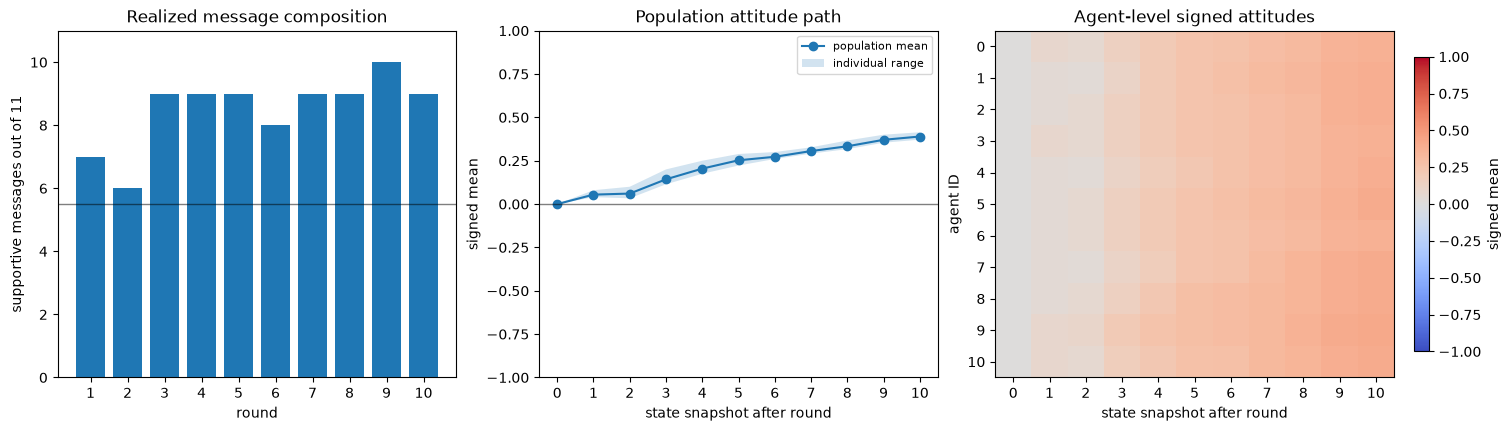

,agent_id,a,b,mean,signed_mean,concentration,p_support_message
0,0,9.6,4.4,0.6857,0.3714,14.0,0.9267
1,1,9.7,4.3,0.6929,0.3857,14.0,0.9344
2,2,9.7,4.3,0.6929,0.3857,14.0,0.9344
3,3,9.6,4.4,0.6857,0.3714,14.0,0.9267
4,4,9.7,4.3,0.6929,0.3857,14.0,0.9344
5,5,9.8,4.2,0.7000,0.4000,14.0,0.9415
6,6,9.6,4.4,0.6857,0.3714,14.0,0.9267
7,7,9.8,4.2,0.7000,0.4000,14.0,0.9415
8,8,9.8,4.2,0.7000,0.4000,14.0,0.9415
9,9,9.9,4.1,0.7071,0.4143,14.0,0.9479


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

axes[0].bar(
    round_messages["round"],
    round_messages["n_support_messages"],
    label="supportive messages",
)
axes[0].axhline(CONFIG.agent_count / 2.0, color="black", linewidth=1.0, alpha=0.5)
axes[0].set(
    title="Realized message composition",
    xlabel="round",
    ylabel="supportive messages out of 11",
    xticks=range(1, CONFIG.rounds + 1),
    ylim=(0, CONFIG.agent_count),
)

axes[1].plot(
    round_states["round"],
    round_states["population_signed_mean"],
    marker="o",
    label="population mean",
)
axes[1].fill_between(
    round_states["round"],
    round_states["minimum_signed_mean"],
    round_states["maximum_signed_mean"],
    alpha=0.2,
    label="individual range",
)
axes[1].axhline(0.0, color="black", linewidth=1.0, alpha=0.5)
axes[1].set(
    title="Population attitude path",
    xlabel="state snapshot after round",
    ylabel="signed mean",
    xticks=range(0, CONFIG.rounds + 1),
    ylim=(-1, 1),
)
axes[1].legend(fontsize=8)

agent_round_matrix = state_history.pivot(
    index="agent_id", columns="round", values="signed_mean"
).sort_index()
image = axes[2].imshow(
    agent_round_matrix.to_numpy(),
    aspect="auto",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
)
axes[2].set_xticks(range(CONFIG.rounds + 1), range(CONFIG.rounds + 1))
axes[2].set_yticks(range(CONFIG.agent_count), agent_round_matrix.index)
axes[2].set(
    title="Agent-level signed attitudes",
    xlabel="state snapshot after round",
    ylabel="agent ID",
)
colorbar = fig.colorbar(image, ax=axes[2], shrink=0.85)
colorbar.set_label("signed mean")

plt.show()

final_states = state_history[state_history["round"] == CONFIG.rounds][
    ["agent_id", "a", "b", "mean", "signed_mean", "concentration", "p_support_message"]
].reset_index(drop=True)
display(final_states.round(4))


## 9. Deterministic, boundary, neutrality, and schedule checks

These checks establish software behavior only. They test equations, event counts, self-exclusion, equal exposure, concentration accounting, no-learning behavior, reproducibility, and iteration-order invariance. They do not validate the Beta mechanism or its parameter values.


In [7]:
def _canonical(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    return frame.sort_values(columns).reset_index(drop=True)


def run_checks(config: BaselineConfig, results: dict[str, pd.DataFrame]) -> pd.DataFrame:
    checks: list[dict[str, str]] = []

    def verify(check_id: str, purpose: str, condition: bool) -> None:
        if not bool(condition):
            raise AssertionError(f"{check_id} failed: {purpose}")
        checks.append({"check_id": check_id, "purpose": purpose, "status": "passed"})

    states = results["states"]
    messages = results["messages"]
    exposures = results["exposures"]
    aggregates = results["aggregates"]
    consumed_per_agent = config.agent_count - 1 if config.exclude_self_messages else config.agent_count

    verify("V0-HAND", "fixed 8/3 self-exclusion case matches hand calculation",
           support_producer_counts == MessageCounts(7, 3)
           and oppose_producer_counts == MessageCounts(8, 2)
           and np.isclose(support_producer_after.a, 2.7)
           and np.isclose(oppose_producer_after.b, 2.2))
    verify("V0-MESSAGE-COUNT", "every round produces one message per agent",
           len(messages) == config.agent_count * config.rounds
           and messages.groupby("round").size().eq(config.agent_count).all())
    verify("V0-STATE-COUNT", "initial and post-round state snapshots are complete",
           len(states) == config.agent_count * (config.rounds + 1))
    verify("V0-EXPOSURE-COUNT", "every consumer receives every eligible message",
           len(exposures) == config.rounds * config.agent_count * consumed_per_agent
           and exposures.groupby(["round", "consumer_id"]).size().eq(consumed_per_agent).all())
    verify("V0-NO-SELF", "no agent consumes its own message",
           (exposures["consumer_id"] != exposures["producer_id"]).all())
    verify("V0-SOURCE-EQUALITY", "every produced message reaches the same number of consumers",
           exposures.groupby(["round", "producer_id"]).size().eq(consumed_per_agent).all())
    verify("V0-AGGREGATION", "supportive and opposing counts reconcile to each batch",
           len(aggregates) == config.agent_count * config.rounds
           and aggregates["consumed_total"].eq(consumed_per_agent).all()
           and (aggregates["n_support"] + aggregates["n_oppose"]).eq(aggregates["consumed_total"]).all())
    verify("V0-UPDATE-A", "supportive evidence reconstructs every a transition",
           np.allclose(aggregates["a_after"], aggregates["a_before"] + config.evidence_weight * aggregates["n_support"]))
    verify("V0-UPDATE-B", "opposing evidence reconstructs every b transition",
           np.allclose(aggregates["b_after"], aggregates["b_before"] + config.evidence_weight * aggregates["n_oppose"]))
    verify("V0-CONCENTRATION", "concentration gain is fixed by consumed count and eta",
           np.allclose(
               aggregates["a_after"] + aggregates["b_after"]
               - aggregates["a_before"] - aggregates["b_before"],
               config.evidence_weight * consumed_per_agent,
           ))

    no_learning_config = replace(config, rounds=3, evidence_weight=0.0)
    no_learning_states = run_simulation(no_learning_config)["states"]
    verify("V0-NO-LEARNING", "eta zero leaves all private states unchanged",
           np.allclose(no_learning_states["a"], config.initial_mean * config.initial_concentration)
           and np.allclose(no_learning_states["b"], (1.0 - config.initial_mean) * config.initial_concentration))

    repeated = run_simulation(config)
    for table_name in results:
        pd.testing.assert_frame_equal(results[table_name], repeated[table_name])
    checks.append({"check_id": "V0-REPRODUCIBILITY", "purpose": "same configuration and seed reproduce all histories", "status": "passed"})

    reverse_order = tuple(reversed(range(config.agent_count)))
    reversed_run = run_simulation(config, agent_order=reverse_order)
    sort_keys = {
        "states": ["round", "agent_id"],
        "messages": ["round", "producer_id"],
        "exposures": ["round", "consumer_id", "producer_id"],
        "aggregates": ["round", "consumer_id"],
    }
    for table_name, keys in sort_keys.items():
        pd.testing.assert_frame_equal(
            _canonical(results[table_name], keys),
            _canonical(reversed_run[table_name], keys),
        )
    checks.append({"check_id": "V2-ORDER", "purpose": "reversing activation iteration preserves agent-associated events and states", "status": "passed"})

    verify("V2-NULL-BOUNDARY", "null boundary contains no selective exposure advantage",
           exposures.groupby(["round", "producer_id"]).size().nunique() == 1)
    verify("V0-DOMAINS", "all state and production summaries remain in declared domains",
           states["mean"].between(0.0, 1.0, inclusive="neither").all()
           and states["signed_mean"].between(-1.0, 1.0, inclusive="both").all()
           and states["p_support_message"].between(0.0, 1.0, inclusive="both").all())

    return pd.DataFrame(checks)


VERIFICATION_RESULTS = run_checks(CONFIG, RESULTS)
display(VERIFICATION_RESULTS)
print(f"All {len(VERIFICATION_RESULTS)} deterministic, boundary, neutrality, and schedule checks passed.")


,check_id,purpose,status
0,V0-HAND,fixed 8/3 self-exclusion case matches hand cal...,passed
1,V0-MESSAGE-COUNT,every round produces one message per agent,passed
2,V0-STATE-COUNT,initial and post-round state snapshots are com...,passed
3,V0-EXPOSURE-COUNT,every consumer receives every eligible message,passed
4,V0-NO-SELF,no agent consumes its own message,passed
5,V0-SOURCE-EQUALITY,every produced message reaches the same number...,passed
6,V0-AGGREGATION,supportive and opposing counts reconcile to ea...,passed
7,V0-UPDATE-A,supportive evidence reconstructs every a trans...,passed
8,V0-UPDATE-B,opposing evidence reconstructs every b transition,passed
9,V0-CONCENTRATION,concentration gain is fixed by consumed count ...,passed


All 15 deterministic, boundary, neutrality, and schedule checks passed.


## 10. Observed result for the retained seed

The following compact record is generated from the event and state histories. It reports what occurred in this one synthetic trajectory without promoting that realization into a general population claim.


In [8]:
final_population = state_history[state_history["round"] == CONFIG.rounds]
support_sequence = round_messages["n_support_messages"].astype(int).tolist()
observed_result = pd.DataFrame(
    {
        "quantity": [
            "supportive-message counts by round",
            "initial population signed mean",
            "final population signed mean",
            "final individual signed-mean range",
            "final common concentration",
            "agents with positive final signed mean",
            "highest completed software evidence level",
        ],
        "observed_value": [
            str(support_sequence),
            f"{round_states.loc[round_states['round'].eq(0), 'population_signed_mean'].iloc[0]:.4f}",
            f"{final_population['signed_mean'].mean():.4f}",
            f"[{final_population['signed_mean'].min():.4f}, {final_population['signed_mean'].max():.4f}]",
            f"{final_population['concentration'].iloc[0]:.4f}",
            int(final_population["signed_mean"].gt(0.0).sum()),
            "V2 paired coupling under the declared synthetic null boundary",
        ],
    }
)
display(observed_result)


,quantity,observed_value
0,supportive-message counts by round,"[7, 6, 9, 9, 9, 8, 9, 9, 10, 9]"
1,initial population signed mean,0.0000
2,final population signed mean,0.3896
3,final individual signed-mean range,"[0.3714, 0.4143]"
4,final common concentration,14.0000
5,agents with positive final signed mean,11
6,highest completed software evidence level,V2 paired coupling under the declared syntheti...


## 11. Conditional interpretation and disposition

- Passing the checks establishes that formation, neutral exposure, aggregation, information effect, and synchronous commit are compatible under this synthetic all-other-posts boundary.
- The message-count sequence and attitude path above describe one seeded realization. They do not estimate an expected trajectory or the probability of symmetry breaking.
- Equal exposure verifies the absence of source-selection advantage in this boundary. It does not test opinion-leader or platform mechanisms, which are intentionally absent.
- With 11 binary producers, every round necessarily has a realized majority. Feedback from that majority is a structural consequence of the odd population and the shared broadcast boundary, not evidence of algorithmic bias.
- Constant positive $\eta$ causes concentration to accumulate. This notebook does not decide whether long-run memory decay, bounded evidence, or another update mechanism is needed.
- The initial $\mathrm{Beta}(2,2)$ state, $\eta=0.1$, and posterior-mass production rule remain provisional modeling choices. Successful execution does not calibrate or empirically validate them.

**Disposition:** retain as a coupled null benchmark for researcher inspection. Extraction into shared source code remains unresolved until the researcher accepts or revises the provisional initialization, evidence weight, and production rule. No sibling scenario implementation is changed by this notebook.
